In [1]:
# Cell 1: Libraries
import numpy as np
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize

In [2]:
# Cell 2: Load Iris dataset
iris_data = datasets.load_iris()
features = iris_data.data
targets = iris_data.target

X_train, X_test, y_train, y_test = train_test_split(
    features, targets,
    test_size=0.3,
    random_state=7,
    stratify=targets
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 105
Testing samples: 45


In [3]:
# Cell 3: Try different tree depths
depth_options = [1, 2, 3]

results = []

for depth in depth_options:
    clf = DecisionTreeClassifier(max_depth=depth)
    clf.fit(X_train, y_train)

    train_score = accuracy_score(y_train, clf.predict(X_train))
    test_score = accuracy_score(y_test, clf.predict(X_test))

    results.append((depth, train_score, test_score))

for r in results:
    print(f"Depth {r[0]} -> Train Acc: {r[1]:.3f}, Test Acc: {r[2]:.3f}")

Depth 1 -> Train Acc: 0.667, Test Acc: 0.667
Depth 2 -> Train Acc: 0.971, Test Acc: 0.889
Depth 3 -> Train Acc: 0.981, Test Acc: 0.978


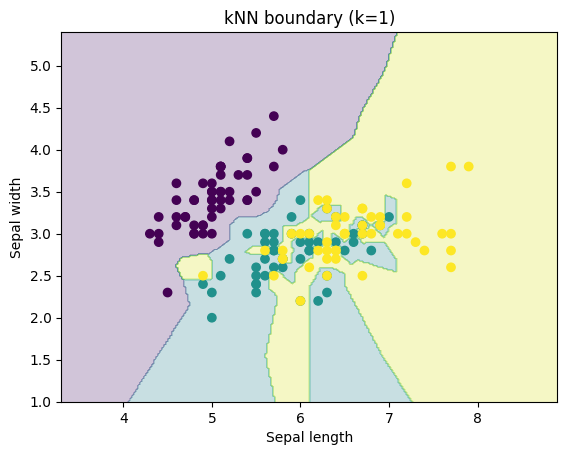

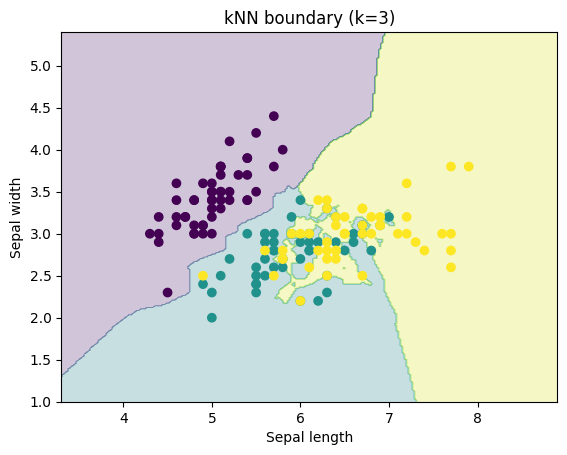

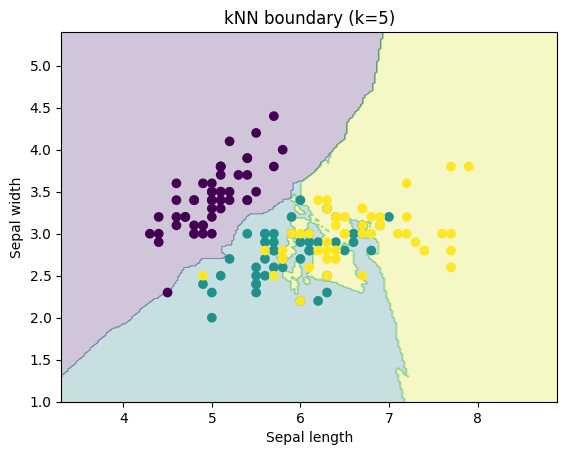

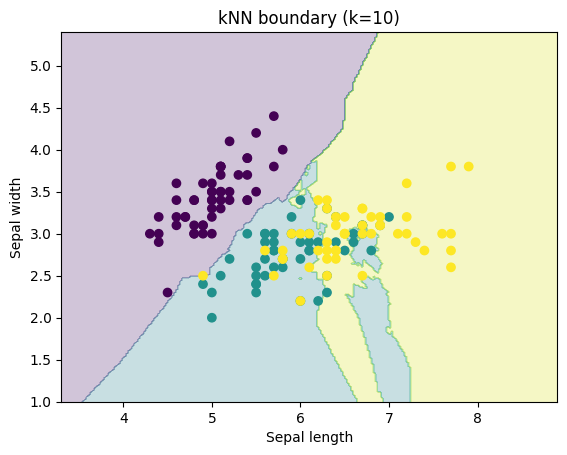

In [4]:
# Cell 4: kNN using only first two features
two_feature_X = features[:, :2]
two_feature_y = targets

neighbors_list = [1, 3, 5, 10]

for n in neighbors_list:
    knn_model = KNeighborsClassifier(n_neighbors=n)
    knn_model.fit(two_feature_X, two_feature_y)

    x_min, x_max = two_feature_X[:,0].min()-1, two_feature_X[:,0].max()+1
    y_min, y_max = two_feature_X[:,1].min()-1, two_feature_X[:,1].max()+1

    grid_x, grid_y = np.meshgrid(
        np.linspace(x_min, x_max, 250),
        np.linspace(y_min, y_max, 250)
    )

    grid_points = np.c_[grid_x.ravel(), grid_y.ravel()]
    predictions = knn_model.predict(grid_points).reshape(grid_x.shape)

    plt.figure()
    plt.contourf(grid_x, grid_y, predictions, alpha=0.25)
    plt.scatter(two_feature_X[:,0], two_feature_X[:,1], c=two_feature_y)
    plt.title(f"kNN boundary (k={n})")
    plt.xlabel("Sepal length")
    plt.ylabel("Sepal width")
    plt.show()

In [5]:
# Cell 5: Train final kNN model
final_knn = KNeighborsClassifier(n_neighbors=5)
final_knn.fit(X_train, y_train)

predictions = final_knn.predict(X_test)

# Confusion matrix
matrix = confusion_matrix(y_test, predictions)
print("Confusion Matrix:\n", matrix)

# Detailed metrics
print("\nClassification Summary:\n")
print(classification_report(y_test, predictions))

Confusion Matrix:
 [[15  0  0]
 [ 0 14  1]
 [ 0  1 14]]

Classification Summary:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.93      0.93      0.93        15
           2       0.93      0.93      0.93        15

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



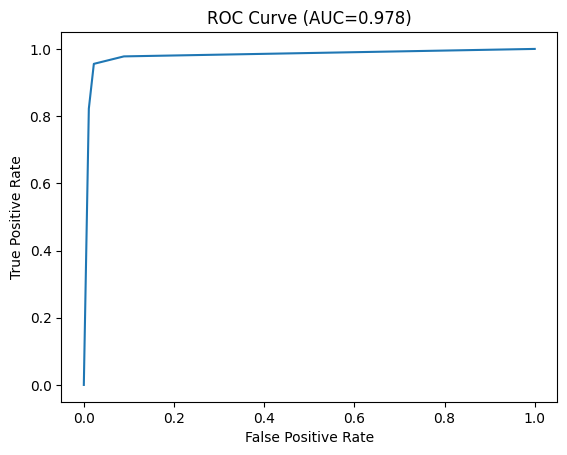

AUC Score: 0.9781481481481483


In [6]:
# Cell 6: ROC + AUC for multiclass
y_test_encoded = label_binarize(y_test, classes=[0,1,2])
probabilities = final_knn.predict_proba(X_test)

fpr, tpr, _ = roc_curve(y_test_encoded.ravel(), probabilities.ravel())
auc_value = roc_auc_score(y_test_encoded, probabilities, multi_class="ovr")

plt.figure()
plt.plot(fpr, tpr)
plt.title(f"ROC Curve (AUC={auc_value:.3f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

print("AUC Score:", auc_value)